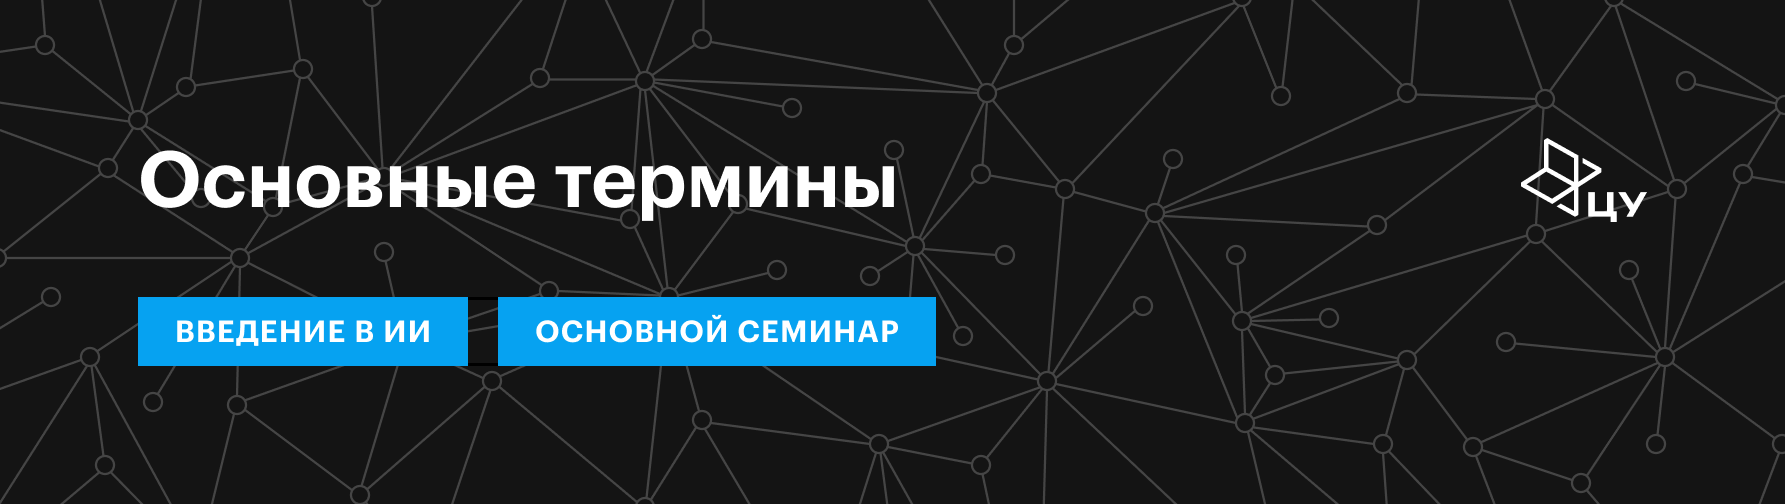

# Семинар по теме «Знакомство с EDA и scikit-learn»

Сегодня ты познакомишься с основами машинного обучения.

Из этого текста ты узнаешь:
- как провести EDA;
- как матрица корреляций помогает установить взаимосвязи;
- как представить данные для обучения модели;
- как разбить данные для решения ML-задачи;
- как выбрать модель для решения задачи;
- как обучить модель и измерить её качество.

### Как представить данные для обучения модели

Если данных много, то удобнее всего воспринимать их в виде таблицы. Поэтому именно с таким форматом работают алгоритмы классического ML.

Разберём, как работать с табличными данными, чтобы обучить модель. Для этого используем датасет машинного обучения [Medical Cost Personal Datasets.](https://www.kaggle.com/datasets/mirichoi0218/insurance)

В нём находятся данные о клиентах страховой компании и стоимости медицинских услуг, которую им компенсировали по страховке.




In [ ]:
# Загружаем данные в среду
!gdown 17H_g6D6Y9s20szMPOfY7cq8xVwEw31ro

Downloading...
From: https://drive.google.com/uc?id=17H_g6D6Y9s20szMPOfY7cq8xVwEw31ro
To: /content/insurance_mod.csv
100% 71.6k/71.6k [00:00<00:00, 67.0MB/s]


In [ ]:
# Импортируем Pandas и NumPy
import pandas as pd
import numpy as np

In [ ]:
# Считываем датасет
df = pd.read_csv('/content/insurance_mod.csv')

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges,charges_euro
0,19,female,27.900,0,yes,southwest,16884.92400,16370.960470
1,18,male,33.770,1,no,southeast,1725.55230,1810.286934
2,28,male,33.000,3,no,southeast,4449.46200,4426.619634
3,33,male,22.705,0,no,northwest,21984.47061,21269.107630
4,32,male,28.880,0,no,northwest,3866.85520,3867.022074
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,10334.777390
1334,18,female,31.920,0,no,northeast,2205.98080,2271.741583
1335,18,female,36.850,0,no,southeast,1629.83350,1718.348414
1336,21,female,25.800,0,no,southwest,2007.94500,2081.526929



В строках записаны наблюдения. В датасете 1338 строк —  это значит, что у нас есть данные примерно о 1338 людях. Их может быть меньше, если в датасете есть несколько наблюдений по одному человеку.

В столбцах перечислены переменные (синоним — атрибуты). Они описывают характеристики каждого наблюдения.

По названию можно определить, какую информацию они содержат:

* `age` — возраст клиента;
* `sex` — пол клиента;
* `bmi` — индекс массы тела клиента (вес, разделённый на рост в метрах в квадрате);
* `children` — количество детей у клиента;
* `smoker` — курит ли клиент;
* `region` — регион проживания клиента;
* `charges` — стоимость страховых услуг;
* `charges_euro` — стоимость страховых услуг в евро (по курсу на момент выплат).


Целевая переменная, значение которой нужно предсказать, — это стоимость страховых услуг `charges`.


## Предобработка данных и EDA


Начнём с pandas и первичного анализа данных: посмотрим структуру датасета и основные характеристики признаков.


### Задание 1




В описании датасета указано, что все столбцы, которые отображаются как `object`, должны быть строками.

Проверь это — выведи типы данных всех столбцов с типом `object`.


In [ ]:
# Напиши код здесь

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [ ]:
print(df.iloc[0, 1])
print(type(df.iloc[0, 1]))

print(df.iloc[0, 4])
print(type(df.iloc[0, 4]))

print(df.iloc[0, 5])
print(type(df.iloc[0, 5]))

female
<class 'str'>
yes
<class 'str'>
southwest
<class 'str'>


### Задание 2



Внеси в датасет данные о дедушке из Америки: ему 74 года, есть трое детей, курит сигары и страховка обошлась ему в 1500 долларов.

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [ ]:
new_data = {'age': 74, 'sex': 'male', 'bmi': np.nan, 'children': 3, 'smoker': 'yes', 'region': np.nan, 'charges': 1500, 'charges_euro': np.nan}
df.loc[len(df)] = new_data
display(df.tail())

,age,sex,bmi,children,smoker,region,charges,charges_euro
1334,18,female,31.92,0,no,northeast,2205.9808,2271.741583
1335,18,female,36.85,0,no,southeast,1629.8335,1718.348414
1336,21,female,25.80,0,no,southwest,2007.9450,2081.526929
1337,61,female,29.07,0,yes,northwest,29141.3603,28143.345980
1338,74,male,NaN,3,yes,NaN,1500.0000,NaN


### Задание 3

Теперь выведи все основные статистики датасета: какой у него размер, какие средние у признаков, какой разброс и другие.



In [ ]:
# Напиши код здесь

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [ ]:
df.describe()

,age,bmi,children,charges,charges_euro
count,1339.000000,1338.000000,1339.000000,1339.000000,1338.000000
mean,39.233010,30.663397,1.096341,13261.631808,12899.208423
std,14.076858,6.098187,1.206166,12109.757796,11631.743298
min,18.000000,15.960000,0.000000,1121.873900,1230.449967
25%,27.000000,26.296250,0.000000,4729.002375,4705.959051
50%,39.000000,30.400000,1.000000,9377.904700,9164.385647
75%,51.000000,34.693750,2.000000,16622.107580,16135.625375
max,74.000000,53.130000,5.000000,63770.428010,61404.787140


In [ ]:
df.describe(include="object")

,sex,smoker,region
count,1339,1339,1338
unique,2,2,4
top,male,no,southeast
freq,677,1064,364


Теперь известны эти особенности данных датасета.
- Средний возраст клиента — 39 лет, причём он достаточно хорошо совпадает с медианой.
- Индекс массы тела — 30,66, его распределение без перекосов.
- В датасете есть клиенты с пятью детьми, но это исключение из правил. В основном у клиентов или совсем нет детей, или один-два ребёнка.
- Стоимость страховых услуг распределена неравномерно.
- Датасет сбалансирован по признаку `sex`.

### Графики распределений

Построим общие графики распределений всех признаков. Мы могли бы разбить данные на бины, собрать всё в массивы и отрисовать при помощи matplotlib. Но тогда размер бина надо подбирать под каждый признак отдельно. Поэтому применим другой способ.

Воспользуемся библиотекой [seaborn](https://seaborn.pydata.org/tutorial.html) — это надстройка над matplotlib, которая упрощает создание визуализации. У seaborn меньше возможностей для манёвров, но с ней можно быстрее проанализировать данные.

Составим одинаковые графики с помощью matplotlib и seaborn и сравним их. В seaborn для этого удобно использовать функцию [histplot()](https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn-histplot) — она строит гистограммы распределений и позволяет быстро посмотреть данные без ручной настройки параметров.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns # Найдём числовые признаки
categorical_cols = df.select_dtypes(include='object').columns # Найдём категориальные признаки

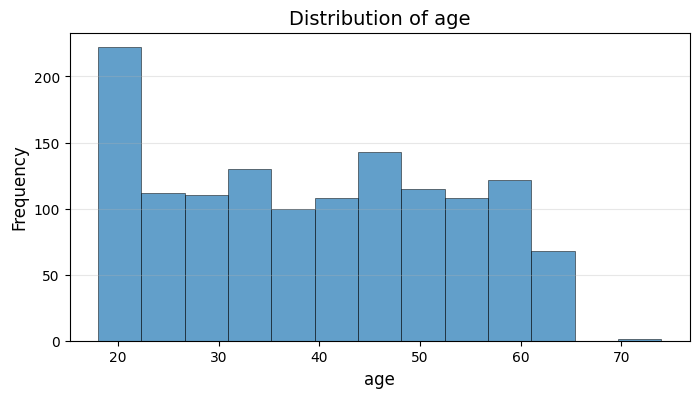

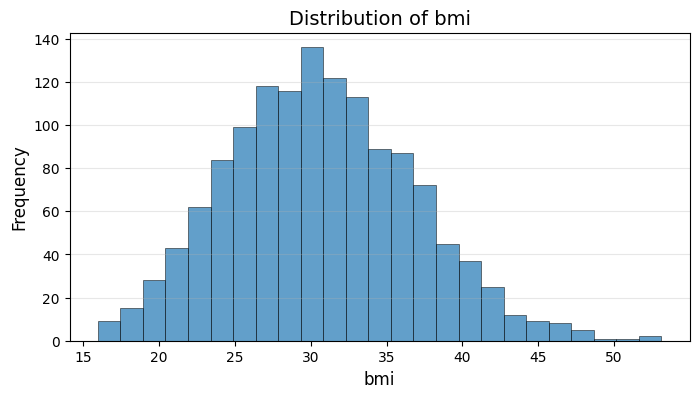

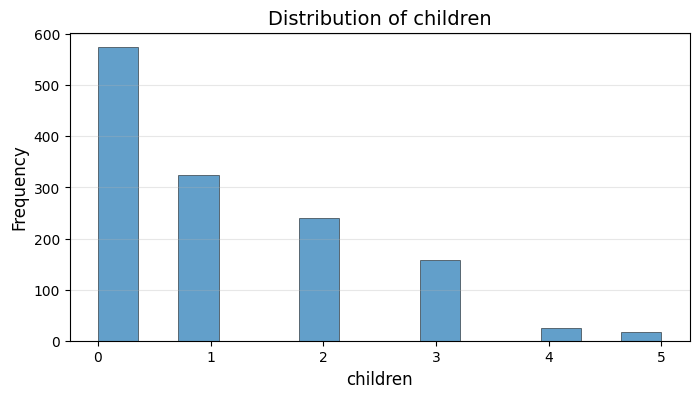

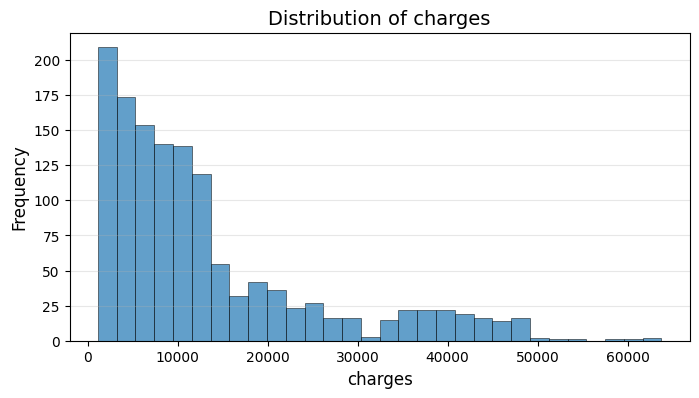

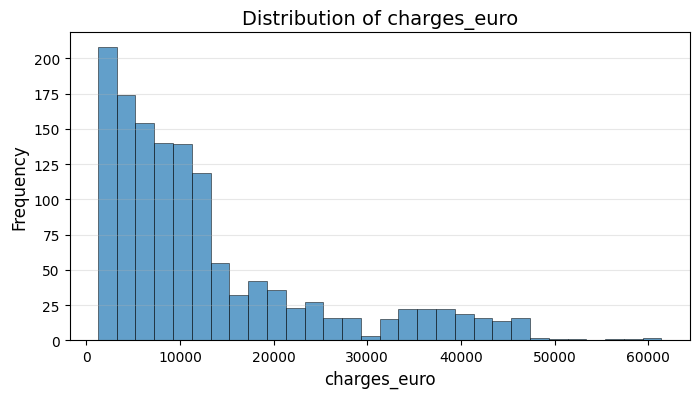

In [ ]:
# Код для matplotlib

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins='auto', alpha=0.7, edgecolor='black', linewidth=0.5)
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.show()


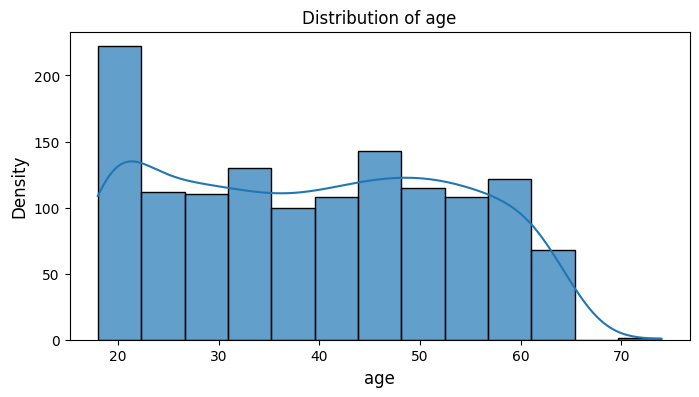

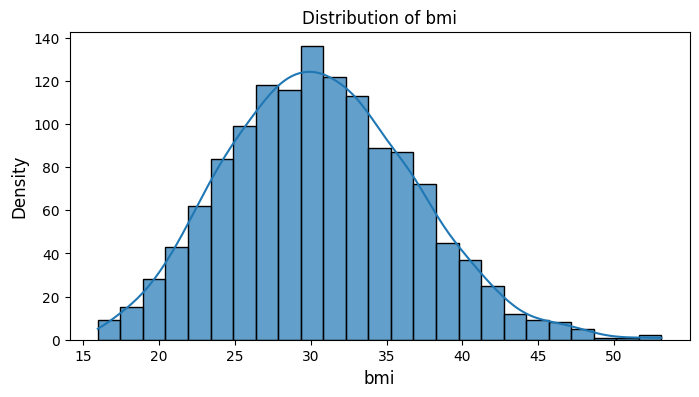

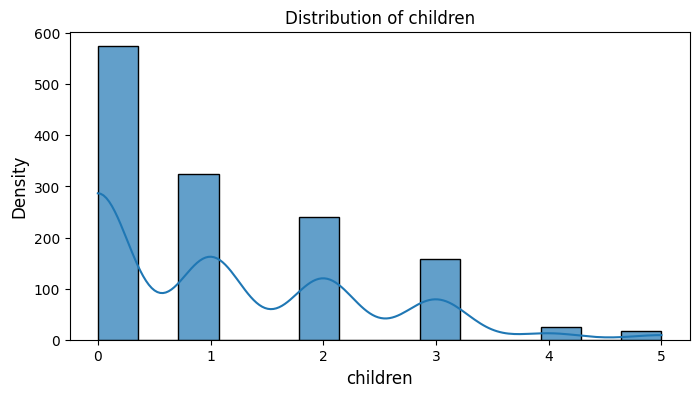

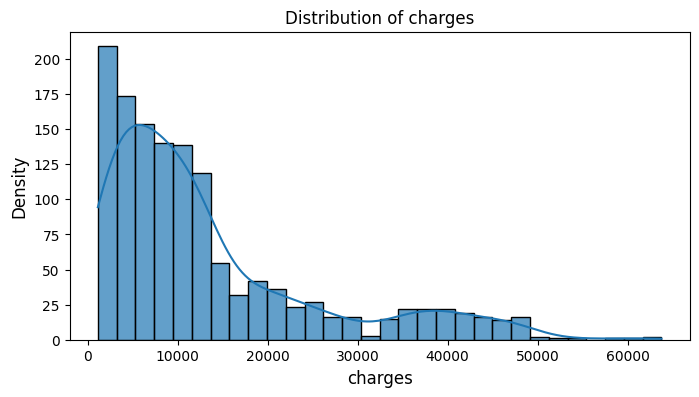

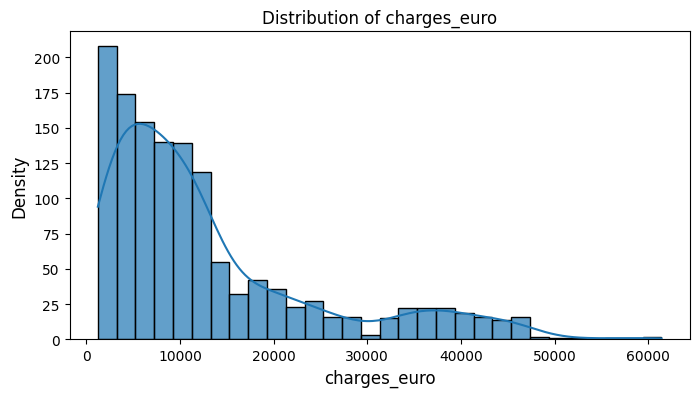

In [ ]:
# Код для seaborn

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, kde=True, alpha=0.7)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.show()


Разница невелика, но в первом случае явно указывали столбец, который нужно отрисовать, а во втором — лишь его название.

Посмотрим на графики парных распределений. Здесь matplotlib смотрится уже не так элегантно ;(

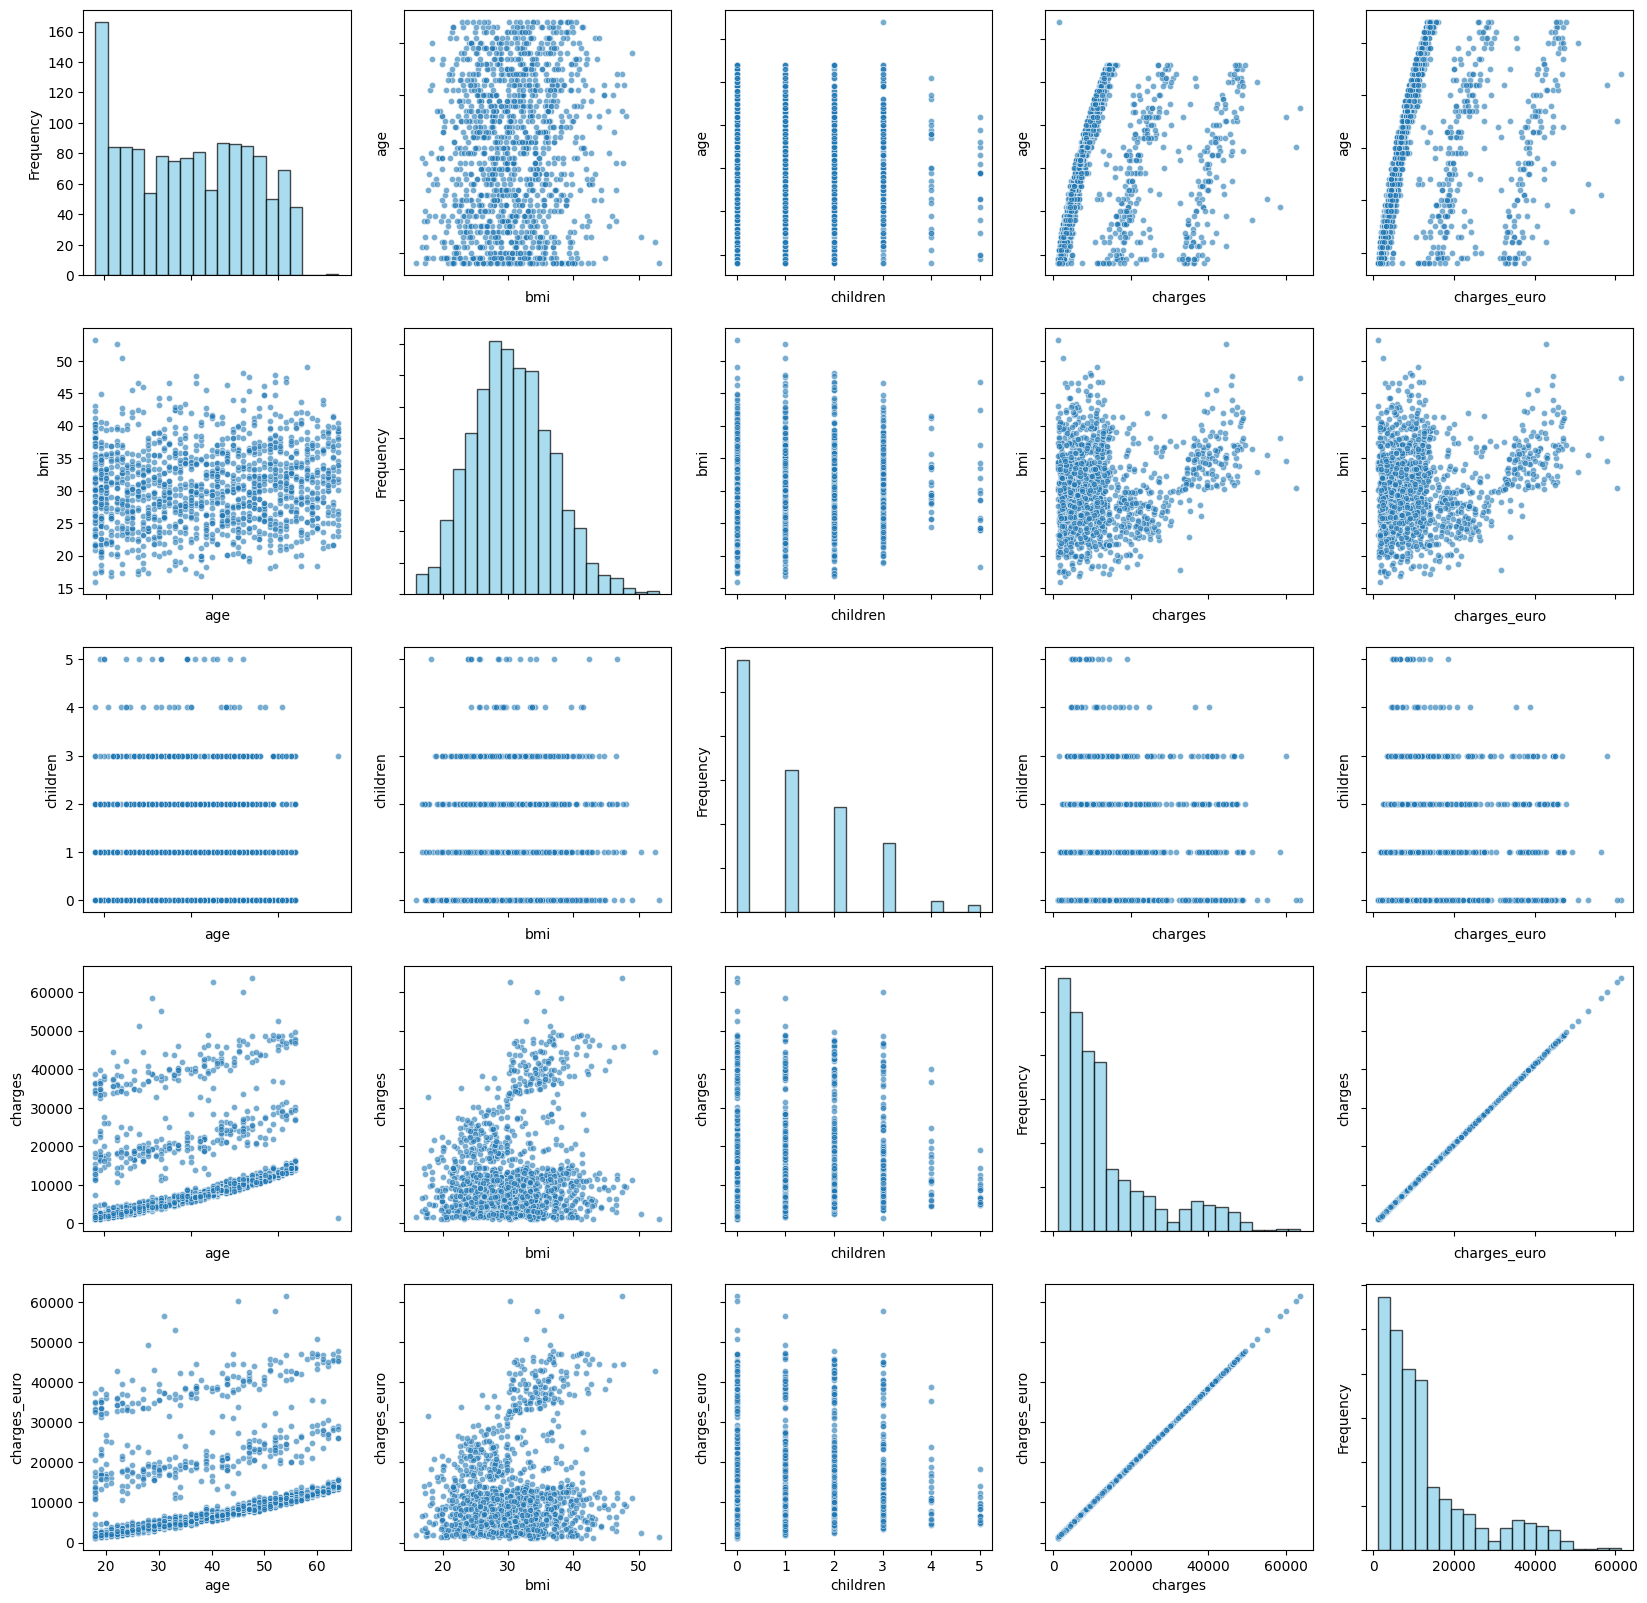

In [ ]:
n = len(numerical_cols)

fig, axes = plt.subplots(n, n, figsize=(4*n, 4*n))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        if i == j:
            # Диагональ: гистограмма распределения
            ax.hist(df[numerical_cols[i]].dropna(), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
            ax.set_ylabel('Frequency')
        else:
            # Недиагональ: точечная диаграмма
            x = df[numerical_cols[j]]
            y = df[numerical_cols[i]]
            ax.scatter(x, y, alpha=0.6, s=20, color='tab:blue', edgecolors='white', linewidth=0.5)
            ax.set_xlabel(numerical_cols[j])
            ax.set_ylabel(numerical_cols[i])

        # Удаляем лишние метки для экономии места
        if i < n - 1:
            ax.xaxis.set_ticklabels([])
        if j > 0:
            ax.yaxis.set_ticklabels([])

plt.show()


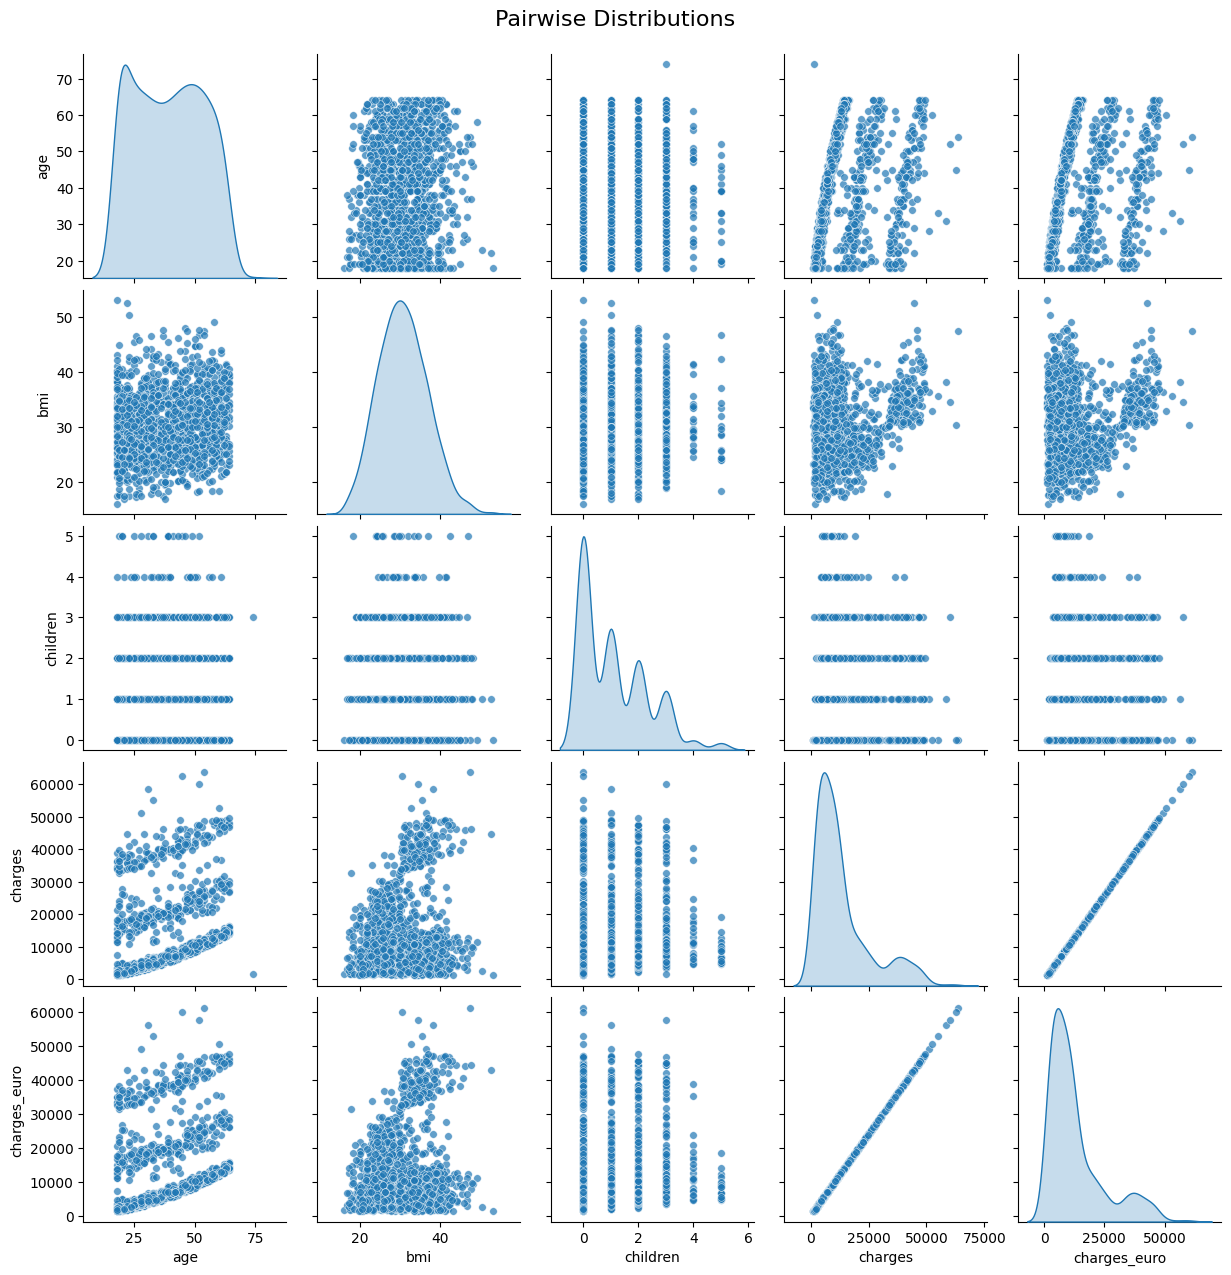

In [ ]:
# Теперь реализация на seaborn

sns.pairplot(data=df[numerical_cols],diag_kind='kde', plot_kws={'alpha': 0.7, 's': 30},  height=2.5)
plt.suptitle("Pairwise Distributions", y=1.02, fontsize=16)
plt.show()

### Выводы
 Датасет сбалансирован по всем признакам, за исключением признака `smoke`.

 Что делать дальше, зависит от задачи. Если признак определяющий (например, в вопросах страхования жизни), то такой дисбаланс классов может исказить оценку качества модели.

 Представим ситуацию: в большинстве случаев курящим людям отказывают в страховании жизни, когда они составляют основу датасета. Тогда «глупая модель» может взять за основу этот признак и всем, кто курит, отказывать, не учитывая дополнительную информацию.

 Не зная о дисбалансе, можно посчитать такую модель лучшей, несмотря на то, что она выдаёт baseline-результат.

### Как влияет дисбаланс классов в нашем случае

В нашем случае дисбаланс классов — естественный. По официальной статистике в мире курит примерно 20% людей. Попробуем обучать модели с несбалансированным признаком.

Скорее всего, он не будет решающим, и дисбаланс никак нам не помешает.

### Что делать, если дисбаланс мешает обучению модели


*   Попытаться найти больше данных о редких классах.
*   Убрать часть данных из более распространённых классов, чтобы модель обращала больше внимания на редкие классы.
*   Сгенерировать объекты, которые очень похожи на объекты редких классов.

### Простая обработка категориальных признаков

В датасете значения некоторых переменных представлены текстом. Большинство ML-моделей работают только с числами, поэтому такие признаки необходимо предварительно преобразовать.

Воспользуемся методом OHE — One-Hot Encoding. Он из каждой категориальной переменной делает $n–1$, новую переменную, где $n$ — число категорий в нашей переменной.

Пример, как работает этот метод.


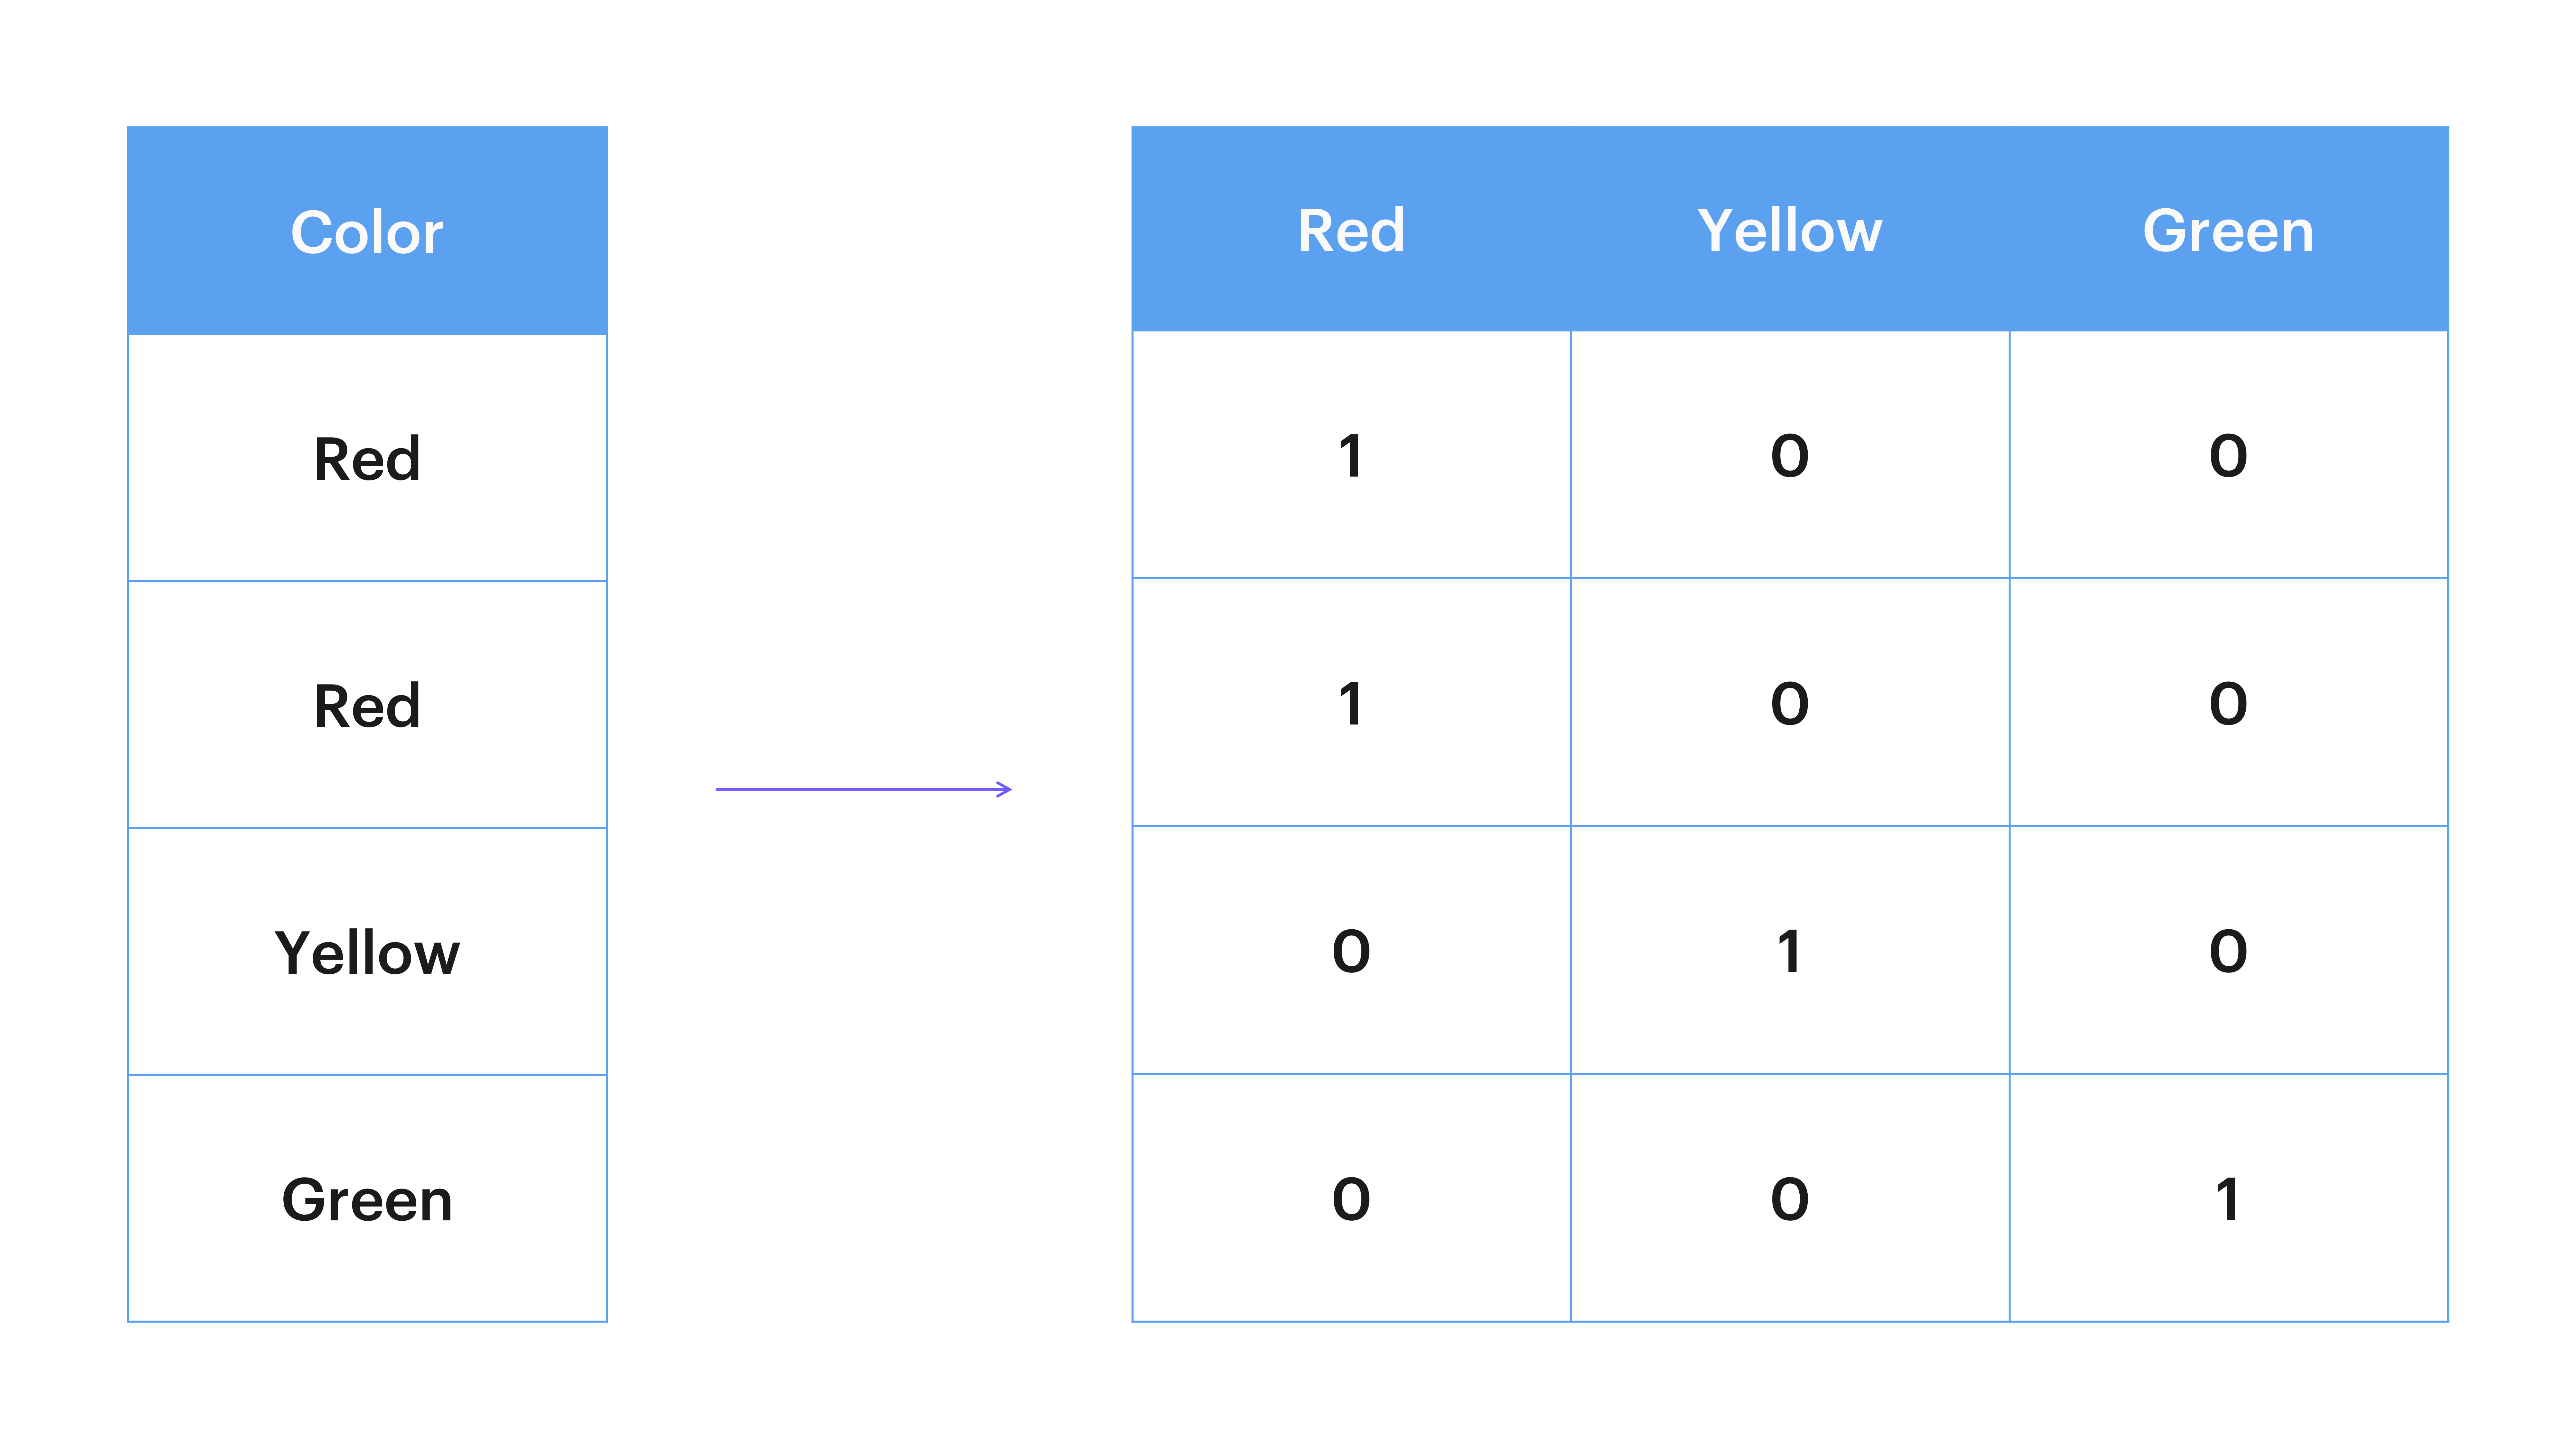


В некоторых пакетах обработка категориальных переменных встроена, чтобы не выполнять однотипные действия каждый раз. Применим функционал одной из таких библиотек.

> **scikit-learn** (sklearn) — популярный пакет для машинного обучения, который содержит в себе как сами модели машинного обучения, так и различный функционал для их качественного обучения и валидации.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# Применим OHE к нашим данным
ohe = OneHotEncoder()
# Выбираем категориальные переменные

df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

In [ ]:
df_encoded

,age,bmi,children,charges,charges_euro,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,16370.960470,False,True,False,False,True
1,18,33.770,1,1725.55230,1810.286934,True,False,False,True,False
2,28,33.000,3,4449.46200,4426.619634,True,False,False,True,False
3,33,22.705,0,21984.47061,21269.107630,True,False,True,False,False
4,32,28.880,0,3866.85520,3867.022074,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1334,18,31.920,0,2205.98080,2271.741583,False,False,False,False,False
1335,18,36.850,0,1629.83350,1718.348414,False,False,False,True,False
1336,21,25.800,0,2007.94500,2081.526929,False,False,False,False,True
1337,61,29.070,0,29141.36030,28143.345980,False,True,True,False,False


### Продвинутая обработка категориальных признаков

На практике категориальные признаки можно кодировать разными способами в зависимости от данных и требований модели, например:

*   **Label Encoding** — преобразует категории в числовые значения (например, CHAS → {«Нет», «Да»} → {0, 1});
*   **Ordinal Encoding** — также преобразует категории в числовые значения, но требует явного указания, какой категории какой номер присвоить (например, CHAS → {0: «Красный», 1: «Зелёный», 2: «Синий»} → {0, 1, 2}).






Признак `region` представлен в виде строк — всего четыре уникальных региона.

In [ ]:
df["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast', nan],
      dtype=object)

### Задание 4
Присвой каждой категории региона номер, а результат помести в столбец `region_num`.

In [ ]:
# Создай словарь для маппинга регионов в числа
region_mapping = {
# Напиши код здесь
}

# Примени маппинг к столбцу «region»
# Напиши код здесь


#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [ ]:
# Создаём словарь для маппинга регионов в числа
region_mapping = {
    'southwest': 1,
    'southeast': 2,
    'northwest': 3,
    'northeast': 4
}

# Применяем маппинг к столбцу «region» и создаём новый столбец «region_num»
df['region_num'] = df['region'].map(region_mapping)

# Выводим первые несколько строк DataFrame с новым столбцом
df.head()

,age,sex,bmi,children,smoker,region,charges,charges_euro,region_num
0,19,female,27.900,0,yes,southwest,16884.92400,16370.960470,1.0
1,18,male,33.770,1,no,southeast,1725.55230,1810.286934,2.0
2,28,male,33.000,3,no,southeast,4449.46200,4426.619634,2.0
3,33,male,22.705,0,no,northwest,21984.47061,21269.107630,3.0
4,32,male,28.880,0,no,northwest,3866.85520,3867.022074,3.0


Label Encoder и Ordinal Encoder сделают то же самое, только быстрее и проще.

In [ ]:
# Преобразуем признак «region» при помощи Label Encoding
from sklearn.preprocessing import LabelEncoder

label_encoder_region = LabelEncoder()
df['region_num2'] = label_encoder_region.fit_transform(df['region'])

df

,age,sex,bmi,children,smoker,region,charges,charges_euro,region_num,region_num2
0,19,female,27.900,0,yes,southwest,16884.92400,16370.960470,1.0,3
1,18,male,33.770,1,no,southeast,1725.55230,1810.286934,2.0,2
2,28,male,33.000,3,no,southeast,4449.46200,4426.619634,2.0,2
3,33,male,22.705,0,no,northwest,21984.47061,21269.107630,3.0,1
4,32,male,28.880,0,no,northwest,3866.85520,3867.022074,3.0,1
...,...,...,...,...,...,...,...,...,...,...
1334,18,female,31.920,0,no,northeast,2205.98080,2271.741583,4.0,0
1335,18,female,36.850,0,no,southeast,1629.83350,1718.348414,2.0,2
1336,21,female,25.800,0,no,southwest,2007.94500,2081.526929,1.0,3
1337,61,female,29.070,0,yes,northwest,29141.36030,28143.345980,3.0,1


In [ ]:
# Преобразуем признак «region» при помощи Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder

# Вариант 1: Создаем новый DataFrame без NaN в 'region'
df_clean = df.dropna(subset=['region']).copy()  # Добавляем .copy() чтобы избежать предупреждения

# Определяем порядок категорий в соответствии с желаемым числовым маппингом
ordinal_encoder_region = OrdinalEncoder(categories=[['southwest', 'northeast', 'southeast', 'northwest']])
df_clean['region_num3'] = ordinal_encoder_region.fit_transform(df_clean[['region']])

df_clean

,age,sex,bmi,children,smoker,region,charges,charges_euro,region_num,region_num2,region_num3
0,19,female,27.900,0,yes,southwest,16884.92400,16370.960470,1.0,3,0.0
1,18,male,33.770,1,no,southeast,1725.55230,1810.286934,2.0,2,2.0
2,28,male,33.000,3,no,southeast,4449.46200,4426.619634,2.0,2,2.0
3,33,male,22.705,0,no,northwest,21984.47061,21269.107630,3.0,1,3.0
4,32,male,28.880,0,no,northwest,3866.85520,3867.022074,3.0,1,3.0
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,10334.777390,3.0,1,3.0
1334,18,female,31.920,0,no,northeast,2205.98080,2271.741583,4.0,0,1.0
1335,18,female,36.850,0,no,southeast,1629.83350,1718.348414,2.0,2,2.0
1336,21,female,25.800,0,no,southwest,2007.94500,2081.526929,1.0,3,0.0


In [ ]:
df

,age,sex,bmi,children,smoker,region,charges,charges_euro,region_num,region_num2,region_num3
0,19,female,27.900,0,yes,southwest,16884.92400,16370.960470,1,3,0.0
1,18,male,33.770,1,no,southeast,1725.55230,1810.286934,2,2,2.0
2,28,male,33.000,3,no,southeast,4449.46200,4426.619634,2,2,2.0
3,33,male,22.705,0,no,northwest,21984.47061,21269.107630,3,1,3.0
4,32,male,28.880,0,no,northwest,3866.85520,3867.022074,3,1,3.0
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,10334.777390,3,1,3.0
1334,18,female,31.920,0,no,northeast,2205.98080,2271.741583,4,0,1.0
1335,18,female,36.850,0,no,southeast,1629.83350,1718.348414,2,2,2.0
1336,21,female,25.800,0,no,southwest,2007.94500,2081.526929,1,3,0.0


### Задание 5

В чём преимущества такого кодирования признаков? В чём недостатки?



#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

**Преимущества**
* Не увеличивает размерность данных.
* Экономит память.

**Недостаток** — такое кодирование может создать ложную порядковую зависимость и запутать модель.


Разберём на примере:

- юг — 0,
- север — 1,
- запад — 2,
- восток — 3.

В случае такого кодирования модель может подумать, что юг совершенно не влияет на ответ, а между севером и западом такое же «расстояние», как между западом и востоком.

Такая ложная зависимость помешает модели извлечь полезные данные из признака, хотя связь между местом и стоимостью жилья (целевой переменной) вполне могла быть:

- на юге дома более востребованные из-за моря, поэтому их покупают по более высоким ценам;
- на севере, наоборот, менее популярны, поэтому в среднем цены там ниже;
- на западе и востоке дома находятся посередине ценового диапазона.

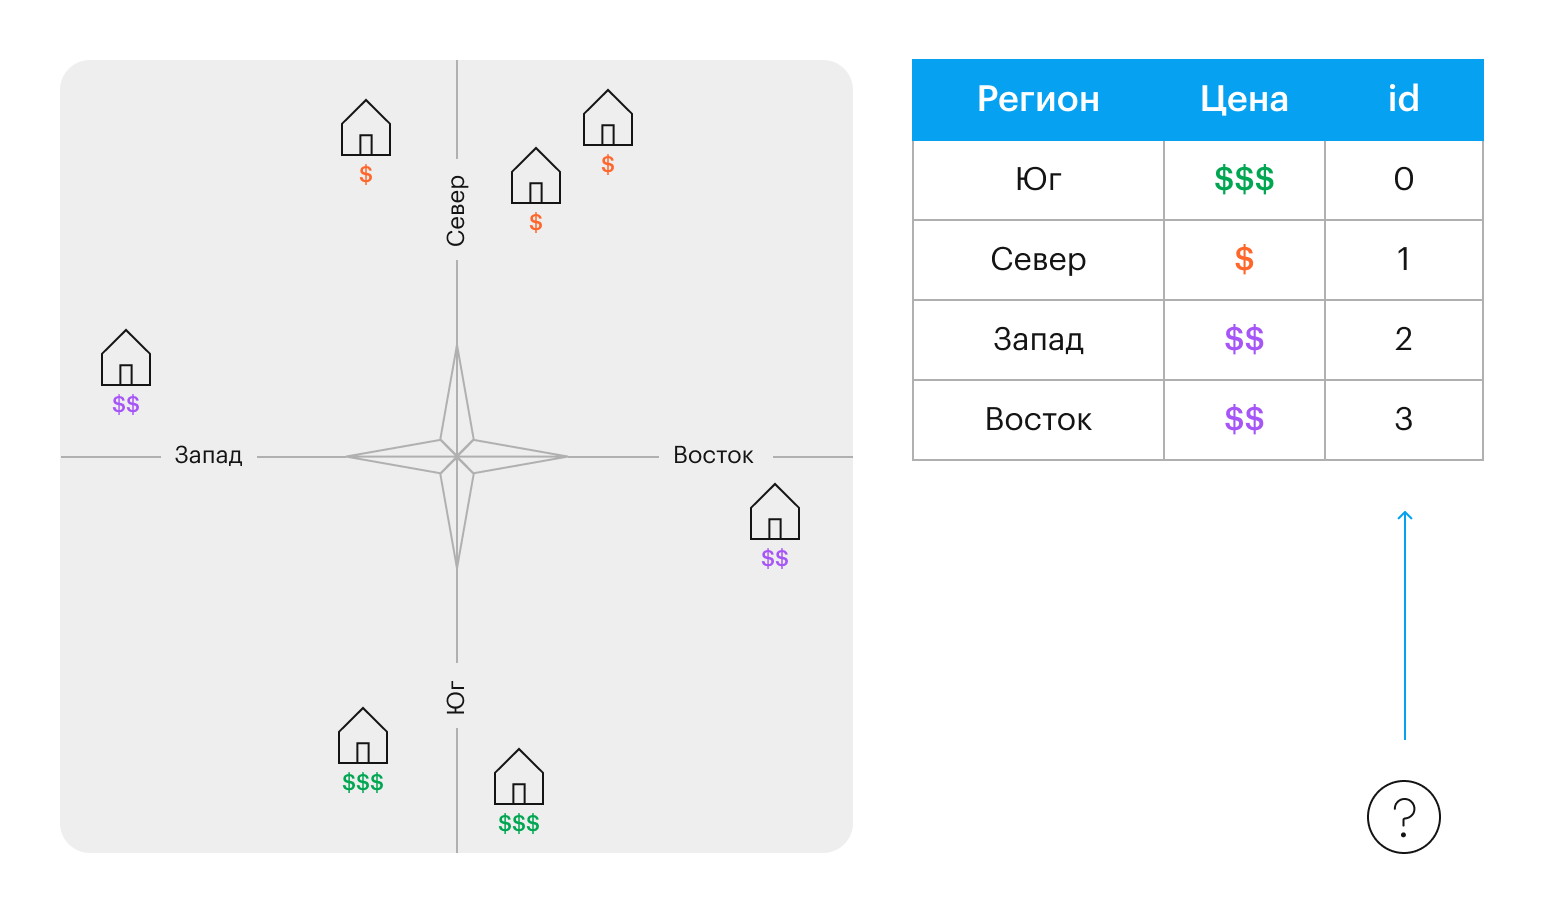

### Target Encoding

Разбиение по категориям — это хорошая идея преобразования переменной. Возможно, страховки в некоторых регионах в среднем дороже, чем в других. Это нужно зафиксировать и сообщить нашей модели.

В этом нам поможет метод [Mean Target Encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.TargetEncoder.html). Суть метода заключается в следующем:

- разбиваем датасет по категориальной переменной;
- в полученных когортах считаем среднее целевой переменной;
- вместо категориальных признаков вставляем посчитанные для них средние.

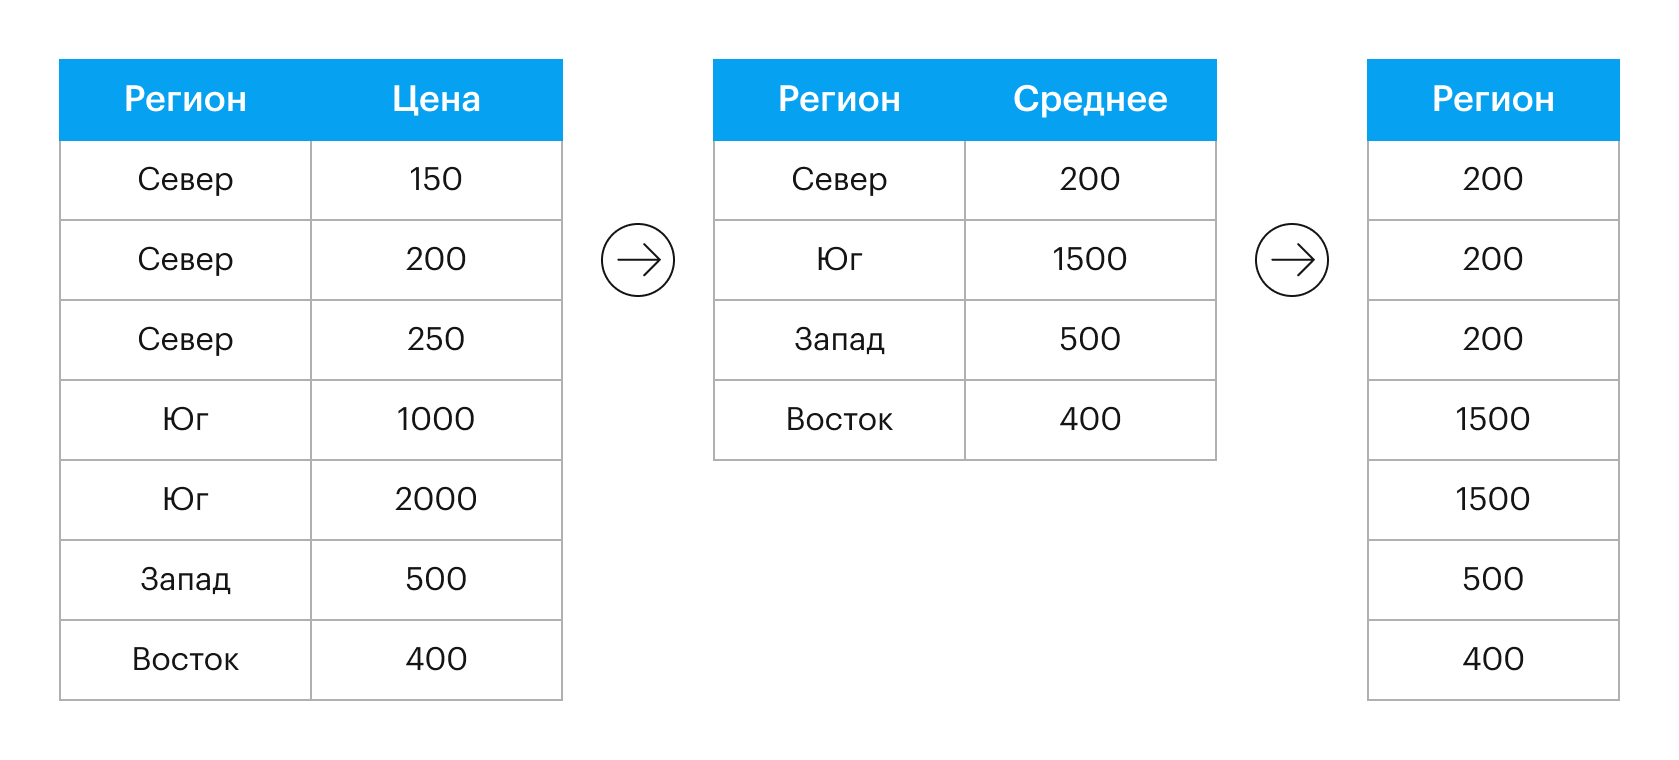

In [ ]:
df = pd.read_csv('/content/insurance_mod.csv')

#### Задание 6

Закодируй признак `region` информацией о среднем значении в столбце `charges`.

In [ ]:
# Напиши код здесь


# Выведи уникальные значения «region» и «region_encoded»


      region  region_encoded
0  southwest         12347.0
3  northwest         12418.0
8  northeast         13406.0
1  southeast         14735.0


#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [ ]:
# Применяем Target Encoding к признаку «region»
region_charges_mean = df.groupby('region')['charges'].mean()
df['region_encoded'] = df['region'].map(region_charges_mean).round()

# Выводим уникальные значения «region» и «region_encoded»
print(df[['region', 'region_encoded']].drop_duplicates().sort_values(by='region_encoded'))

      region  region_encoded
0  southwest         12347.0
3  northwest         12418.0
8  northeast         13406.0
1  southeast         14735.0


#### Задание 7

В чём преимущества и недостатки данного метода? Что будет, если в датасете 100 категорий и 500 объектов?

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

**Преимущества**

- Информативность — метод использует информацию о целевой переменной, что может улучшить качество модели.

- Компактность — не увеличивает размерность данных, в отличие от One-Hot Encoding.

**Недостатки**
- Утечка данных — может создаться признак, который сильно скоррелирован с целевой переменной.

- Нестабильность — чувствительность к выбросам в целевой переменной.

В случае небольшого числа объектов информация утечёт в обучающую выборку. Получится ситуация, когда модели по сути подсказали правильные ответы.

Посмотрим на конкретном примере.


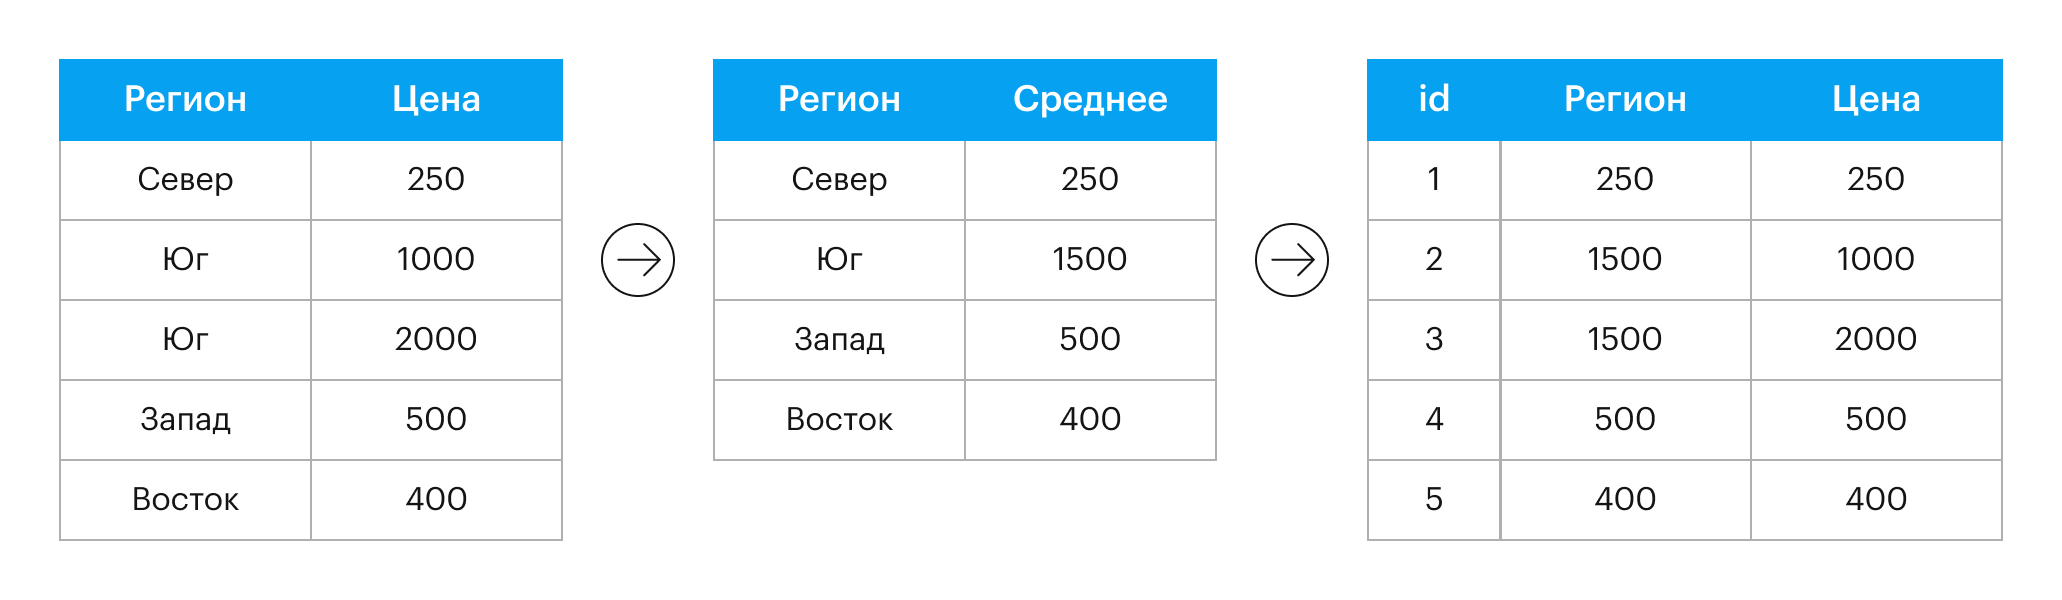

### Поиск корреляции между признаками

Матрица корреляций позволяет установить, есть ли линейные зависимости между величинами. Визуализировать матрицу лучше при помощи метода heatmap —  каждое значение кодируется цветом согласно заданной цветовой шкале.

**Степени зависимости**

- Слабая зависимость (коэффициент корреляции `0,2–0,4`) — рекомендуется оставлять такие признаки. Стоит попытаться установить логическую связь между ними.

- Умеренная зависимость (коэффициент корреляции `0,4–0,85`) — рекомендуется проанализировать причину зависимости. Скорее всего, она будет достаточно очевидной. Если один из признаков не несёт в себе важной информации, можно его исключить или объединить.

- Сильная зависимость (коэффициент корреляции >`0,85`) — скорее всего, признаки дублируют друг друга (например, зарплата сотрудника в долларах и евро), в таком случае один из них крайне желательно исключить из датасета.



<Axes: >

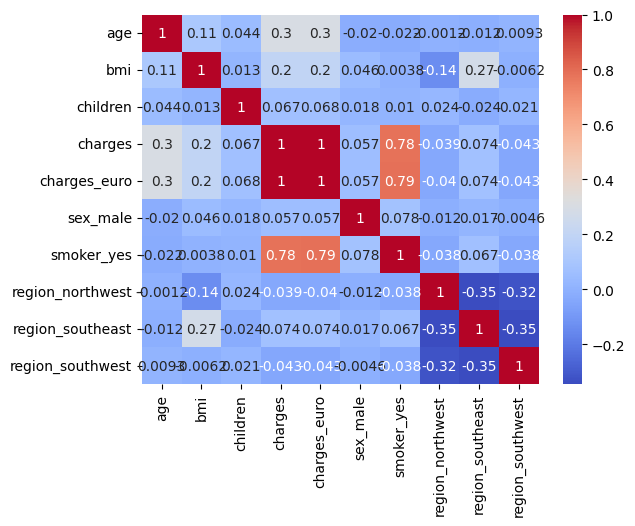

In [ ]:
corr_matrix = df_encoded.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

Выделим для лучшей читаемости коэффициенты больше `0,15` по модулю.

<Axes: >

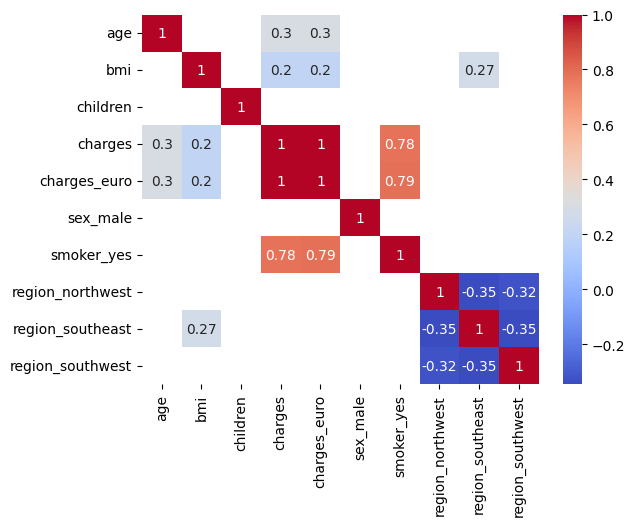

In [ ]:
corr_matrix = df_encoded.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', mask = np.abs(corr_matrix) < 0.15)


### Задание 8

Какие корреляции можно обнаружить в датасете по схеме выше?



#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

Очевидных зависимостей мало, но они есть.

1) Между выплатами в долларах и евро есть сильная корреляция. Это объясняется тем, что на протяжении долгого времени курс доллара к евро не меняется, а следовательно, выплаты в долларах будут почти такими же, как и пересчитанные выплаты в евро.

2) Наибольшая корреляция прослеживается между `smoked_yes` и целевой переменной: `0,79` — это достаточно большой коэффициент. Можно с уверенностью сказать, что у курящих людей более дорогая страховка.

3) Некоторая корреляция прослеживается между возрастом и стоимостью страховых услуг. Вероятно, взрослые люди более склонны страховать своё имущество, или же им просто есть что страховать, в отличие от более молодых.

4) Есть скопление корреляций в правом нижнем углу между признаками региона. Это объясняется очень просто: если в столбце `region_northwest` стоит 1, то в двух других столбцах направления будут стоять 0.

    Если в `region_northwest` стоит 0, тогда имеем три равновероятных варианта (так как признак `region` сбалансирован), следовательно, некоторая зависимость имеется, её и показал нам коэффициент корреляции.




### Нулевая корреляция не означает отсутствие зависимости

Корреляции показывают нам только линейные зависимости между переменными. Если корреляция нулевая, то это не значит, что они никак друг от друга не зависят.

Если бы по корреляции можно было определить, связаны ли как-то между собой данные или нет, то никаких наук о данных просто не было бы: все бы считали корреляции, и этого было бы достаточно.

Посмотрим на искусственно сгенерированные данные и убедимся в этом.



<Axes: >

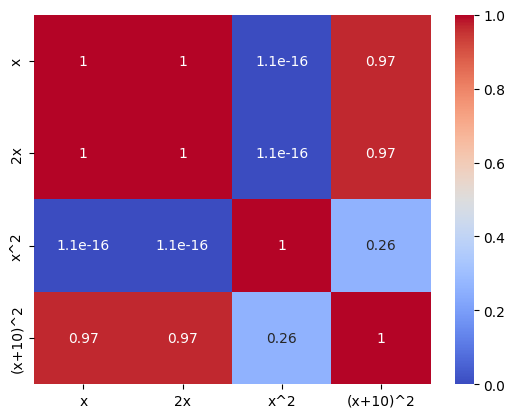

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 20)
df_1 = pd.DataFrame({
    "x": x,
    "2x": 2*x,
    "x^2": x**2,
    "(x+10)^2": (x + 10)**2
})

corr = df_1.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

Признаки $x$ и $2x$ сильно скоррелированы. Это значит, что при росте одного признака вырастет и другой. Это мы точно знаем, потому что они линейно зависимы.

Теперь посмотрим на менее очевидные зависимости.

$x$ и $x^2$ — зависимость квадратичная, однако, корреляция нулевая. Это происходит потому, что на симметричном интервале квадратичная функция сначала убывает, а потом растёт. Из-за этого коэффициент корреляции нулевой.

Иная ситуация с $x$ и $(x+10)^2$. Зависимость опять квадратичная, но тут коэффициент корреляции смог её уловить, потому что возрастание одного признака влечёт возрастание другого.

Чуть более хитро всё обстоит с $x^2$ и $(x+10)^2$: если раскрыть скобки во втором признаке, то мы увидим, что $x^2$ входит в него целиком, однако есть ещё и дополнение $20x+100$. Из-за него коэффициент не 1, однако и 0 он тоже быть не может.

**Вывод**

Нулевая корреляция — не повод останавливаться. Нужно продолжать работать с данными, чему мы и научимся на этом и последующих семинарах, чтобы найти менее тривиальные зависимости.



### Удаление линейно зависимого признака

Если нужно предсказать по остальным признакам выплаты по страховке в долларах, то модель, скорее всего, посмотрит на очень зависимый с нашим таргетом признак и будет выдавать его в качестве ответа.

В реальной жизни пациент приходит в страховую компанию без признака `charges_euro`. Модель должна научиться прогнозировать без этого признака.

Удалим столбец `charges_euro` из датасета, чтобы избежать утечки данных из целевой переменной.





In [ ]:
df = df.drop("charges_euro", axis = 1)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
1337,61,female,29.070,0,yes,northwest,29141.36030


### Разделение выборки


При обучении моделей важно не только добиться хороших предсказаний, но и корректно оценить, насколько модель действительно научилась решать задачу, а не просто запомнила данные.

Используем аналогию, чтобы разобрать, почему это критично.

Студенту выдали набор задач, решая которые, он должен изучить предмет и сдать экзамен. Но вместо того, чтобы находить закономерности, обобщения и понимать принцип решения, он нашёл правильные ответы к задачам и заучил их.
Если экзамен будет состоять из точно таких же задач, студент получит высокий балл, несмотря на то, что ничему не научился.


**Как корректно оценить модель и знания студента?**

Не показывать все возможные задачи заранее. Часть из них оставить для тестирования. Тогда на экзамене студент увидит похожие задачи, но такие, которые он ещё не решал. Если материал усвоен, то сможет с ними справиться.

Тот же принцип работает и в машинном обучении.

Чтобы корректно оценить модель, её проверяют на **отложенной выборке** — данных, которые модель не видела во время обучения. Безусловно, нужно следить, чтобы обучающие и тестовые данные были похожи.

Например, нельзя обучать модель предсказывать цены на дома в неблагополучных районах, а затем тестировать её на домах в центре города: в таком случае результаты не будут отражать реальное качество модели.

**В итоге данные обычно делят на две части:**

- train — данные, на которых модель учится;

- test — данные, на которых проверяем качество модели.

#### Как разбить данные

Перемешивать выборку вручную не требуется, это автоматически сделает специальная функция.

При разделении выборки можно указать признак, по которому важно сохранить баланс данных. В этом случае распределения в обучающей и тестовой выборках будут совпадать.

> **Примечание.** Если данных очень много, то, перемешав данные случайным образом, мы получим примерно одинаковые распределения.

Для разделения данных на обучающую и тестовую выборки используем функцию `train_test_split` из библиотеки scikit-learn.

In [ ]:
# Импортируем пакеты для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Функция для разделения данных на train и val
from sklearn.model_selection import train_test_split

Проще всего разделять данные по категориальной переменной, значения которой строго определены. В наших данных это `sex`, `smoker` и `region`.

Попробуем разделить по полу `sex`.

In [ ]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded["charges"]

display(X)
display(y)

,age,bmi,children,charges_euro,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16370.960470,False,True,False,False,True
1,18,33.770,1,1810.286934,True,False,False,True,False
2,28,33.000,3,4426.619634,True,False,False,True,False
3,33,22.705,0,21269.107630,True,False,True,False,False
4,32,28.880,0,3867.022074,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1334,18,31.920,0,2271.741583,False,False,False,False,False
1335,18,36.850,0,1718.348414,False,False,False,True,False
1336,21,25.800,0,2081.526929,False,False,False,False,True
1337,61,29.070,0,28143.345980,False,True,True,False,False


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1334,2205.98080
1335,1629.83350
1336,2007.94500
1337,29141.36030


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, # Наши данные
                                                  train_size=0.8, # 80% данных пойдут в обучающую выборку
                                                  shuffle=True, # Перемешиваем данные перед разбиением, по умолчанию всегда включено
                                                  stratify=X['sex_male'], # Опционально, указываем, по какой переменной нужно получить баланс
                                                  random_state=112 # Перемешивание — случайная операция в общем случае. Мы хотим избавиться от случайности, задавая seed. Примерно как в «Майнкрафте», где seed можно задать для генерации мира
                                                  )

In [ ]:
display(X_train)

In [ ]:
display(X_test)

In [ ]:
display(y_train)

In [ ]:
display(y_test)

## Постановка задачи и обучение blackbox-моделей

### Регрессия



Попробуем предсказать столбец `charges`. Так как данные в этом столбце принимают не дискретные значения, то задача относится к регрессии.

Обучим на наших данных наиболее популярные ML-модели и замерим их качество.



#### Популярные ML-модели (от простых к сложным)

На этом этапе не требуется понимать внутреннее устройство алгоритмов — мы используем их как готовые инструменты и сравниваем качество решений. Подробнее с ними ты познакомишься на курсе Machine Learning. Выделены те модели, которые мы затронем в нашем курсе.

**Регрессия**

* **LinearRegression**,
* Lasso,
* SVR,
* **DecisionTreeRegressor**,
* **RandomForestRegressor**,
* CatBoostRegressor,
* XGBRegressor.

#### Линейная регрессия (LinearRegression)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Инициализация и обучение линейной регрессии
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Предсказания на обучающей и валидационной выборках
train_preds = linear_model.predict(X_train)
val_preds = linear_model.predict(X_test)

# Расчёт MSE
mse_train = mean_squared_error(y_train, train_preds)
mse_test = mean_squared_error(y_test, val_preds)

# Расчёт RMSE
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)


print(f'MSE на обучающей выборке: {mse_train}')
print(f'MSE на валидационной выборке: {mse_test}')

print(f'RMSE на обучающей выборке: {rmse_train}')
print(f'RMSE на валидационной выборке: {rmse_test}')

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Есть важная деталь — **в датасете пропущены некоторые значения** `NaN`. Это не число, а неопределённость. ML-модели не умеют работать с такими значениями.

Необходимо очистить датасет от `NaN`, и только тогда пайплайн обучения запустится.

**Способы обработки `NaN`-значений:**

* удалить строки с `NaN`-значениями из датасета;

* заполнить `NaN` наиболее частыми значениями в столбце;

* заполнить `NaN` средним значением по столбцу;

* заполнить `NaN` некоторым «особым» значением, например, −1.


#### Задание 9

Обработай датасет от пропусков любым из предложенных способов и обоснуй своё решение.

In [ ]:
# Напиши код здесь

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [ ]:
df = df.iloc[:-1]
display(df.tail())

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


Теперь повторно запустим обучение модели

In [ ]:
ohe = OneHotEncoder()
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
X = df_encoded.drop('charges', axis=1)
y = df_encoded["charges"]
X_train, X_test, y_train, y_test = train_test_split(X, y, # Наши данные
                                                  train_size=0.8, # 80% данных пойдут в обучающую выборку
                                                  shuffle=True, # Перемешиваем данные перед разбиением, по умолчанию всегда включено
                                                  stratify=X['sex_male'], # Опционально, указываем, по какой переменной нужно получить баланс
                                                  random_state=112 # Перемешивание — случайная операция в общем случае. Мы хотим избавиться от случайности, задавая seed. Примерно как в «Майнкрафте», где seed можно задать для генерации мира
                                                  )



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Инициализация и обучение линейной регрессии
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Предсказания на обучающей и валидационной выборках
train_preds = linear_model.predict(X_train)
val_preds = linear_model.predict(X_test)

# Расчёт MSE
mse_train = mean_squared_error(y_train, train_preds)
mse_test = mean_squared_error(y_test, val_preds)

# Расчёт RMSE
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)


print(f'MSE на обучающей выборке: {mse_train}')
print(f'MSE на валидационной выборке: {mse_test}')

print(f'RMSE на обучающей выборке: {rmse_train}')
print(f'RMSE на валидационной выборке: {rmse_test}')

MSE на обучающей выборке: 37641676.77881442
MSE на валидационной выборке: 32028138.807113368
RMSE на обучающей выборке: 6135.281312117189
RMSE на валидационной выборке: 5659.340845638595


**Результаты**

Одна из самых простых моделей ML — линейная регрессия — показала себя неплохо. Средняя ошибка прогноза у обученной модели — 5,5k.

Это означает, что предсказания модели в среднем отклоняются от реальной стоимости страхования на несколько тысяч. Например, если модель предсказала бы стоимость страховки в 20k, то мы заплатим в реальности от 14k до 26k.

Это серьёзная ошибка, поэтому имеет смысл попробовать более сложные модели и сравнить их качество.



#### Дерево решений (DecisionTreeRegressor)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Инициализация и обучение модели Decision Tree с ограниченной глубиной и минимальным количеством выборок для разделения
tree_model = DecisionTreeRegressor(max_depth=10, min_samples_split=50, random_state=112) # Устанавливаем максимальную глубину и минимальное количество выборок для разделения
tree_model.fit(X_train, y_train)

# Предсказания на обучающей и тестовой выборках
train_preds_tree = tree_model.predict(X_train)
test_preds_tree = tree_model.predict(X_test)

# Расчёт MSE
mse_train_tree = mean_squared_error(y_train, train_preds_tree)
mse_test_tree = mean_squared_error(y_test, test_preds_tree)

# Расчёт RMSE
rmse_train_tree = np.sqrt(mse_train_tree)
rmse_test_tree = np.sqrt(mse_test_tree)


print(f'MSE на обучающей выборке (Decision Tree): {mse_train_tree}')
print(f'MSE на тестовой выборке (Decision Tree): {mse_test_tree}')

print(f'RMSE на обучающей выборке (Decision Tree): {rmse_train_tree}')
print(f'RMSE на тестовой выборке (Decision Tree): {rmse_test_tree}')

MSE на обучающей выборке (Decision Tree): 16940238.969470575
MSE на тестовой выборке (Decision Tree): 24036500.47880123
RMSE на обучающей выборке (Decision Tree): 4115.852155929629
RMSE на тестовой выборке (Decision Tree): 4902.703384746137


**Результаты**

Решающее дерево показало себя значительно лучше. В среднем ошибка прогноза — 4,9k.

Попробуем модель случайного леса.



#### Случайный лес (RandomForestRegressor)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Инициализация и обучение модели Random Forest с ограниченной глубиной и минимальным количеством выборок для разделения
forest_model = RandomForestRegressor(max_depth=3, min_samples_split=50, random_state=112, n_jobs=-1) # Устанавливаем максимальную глубину и минимальное количество выборок для разделения, а также количество ядер
forest_model.fit(X_train, y_train)

# Предсказания на обучающей и тестовой выборках
train_preds_forest = forest_model.predict(X_train)
test_preds_forest = forest_model.predict(X_test)

# Расчёт MSE
mse_train_forest = mean_squared_error(y_train, train_preds_forest)
mse_test_forest = mean_squared_error(y_test, test_preds_forest)

# Расчёт RMSE
rmse_train_forest = np.sqrt(mse_train_forest)
rmse_test_forest = np.sqrt(mse_test_forest)


print(f'MSE на обучающей выборке (Random Forest): {mse_train_forest}')
print(f'MSE на тестовой выборке (Random Forest): {mse_test_forest}')

print(f'RMSE на обучающей выборке (Random Forest): {rmse_train_forest}')
print(f'RMSE на тестовой выборке (Random Forest): {rmse_test_forest}')

MSE на обучающей выборке (Random Forest): 20575616.222358137
MSE на тестовой выборке (Random Forest): 18724289.22393998
RMSE на обучающей выборке (Random Forest): 4536.035297741645
RMSE на тестовой выборке (Random Forest): 4327.1571757841175


**Результат**

Случайный лес показал себя на тестовой выборке лучше, чем дерево решений и линейная регрессия.



#### Мини-пайплайн машинного обучения (на следующем семинаре мы его дополним)
1) EDA: изучаем датасет, анализируем и выдвигаем гипотезы.
2) Предобработка данных, выделение целевой переменной.
3) Выбор ML-модели.
4) Обучение на обучающем датасете (train).
5) Замер метрик на тестовом датасете (test).

### Классификация


#### Наиболее популярные ML-модели для задачи классификации

*  **LogisticRegression** (это не ошибка),
*  SVC,
*  SGDClassifier,
*  KNeighborsClassifier,
*  **DecisionTreeClassifier**,
*  **RandomForestClassifier**,
*  GradientBoostingClassifier.

Попробуем предсказать, является ли человек многодетным. Будем считать его таковым, если у него двое и более детей.

Для удобства весь пайплайн помещён в одну ячейку.

#### Задание 10

В целях экономии времени пайплайн обучения уже написан. Прочитай его и подпиши комментарии.

Оценивай модель при помощи метрики Accuracy.

$$Acc = \frac{1}{n}∑_{i=1}^nI[y_i = \hat{y_i}]\text,  \\
\text{где n — количество наблюдений;} \\
y_i \text{ — истинная метка класса для i-го наблюдения;} \\
\hat{y_i} \text{ — предсказанная метка класса для i-го наблюдения.}$$



In [ ]:
df = pd.read_csv('/content/insurance_mod.csv')

df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

df_encoded['new_goal'] = (df_encoded['children'] > 1).astype(int)

df_encoded = df_encoded.drop('children', axis=1)

X = df_encoded.drop('new_goal', axis=1)
y = df_encoded['new_goal']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=112, stratify=y)

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree_classifier = DecisionTreeClassifier(random_state=112)
tree_classifier.fit(X_train, y_train)

y_pred = tree_classifier.predict(X_test)

# accuracy — точность, доля верно угаданных ответов
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy на тестовой выборке (Decision Tree Classifier): {accuracy}')

display(df_encoded.head())

Accuracy на тестовой выборке (Decision Tree Classifier): 0.8059701492537313


,age,bmi,charges,charges_euro,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,new_goal
0,19,27.900,16884.92400,16370.960470,False,True,False,False,True,0
1,18,33.770,1725.55230,1810.286934,True,False,False,True,False,0
2,28,33.000,4449.46200,4426.619634,True,False,False,True,False,1
3,33,22.705,21984.47061,21269.107630,True,False,True,False,False,0
4,32,28.880,3866.85520,3867.022074,True,False,True,False,False,0


#### Задание 11

Насколько хороши предсказания модели? Как понять, 80% верно угаданных ответов — это много или мало?


#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

Можно посмотреть на график распределения признака `children`. Мы увидим, что соотношение многодетных к немногодетным примерно 1 к 2, следовательно, самая простая модель, выдающая всегда наиболее популярный класс, получит accuracy в районе 65%. Это значит, что 80% — очень хороший прогресс относительно baseline.

Также можно сравнить эту модель с линейным классификатором и взять его за baseline.
